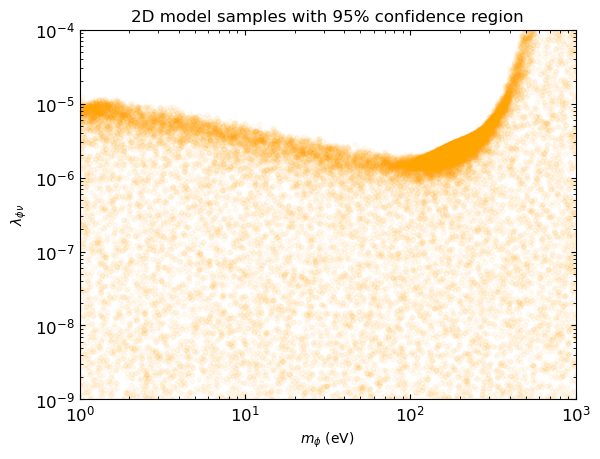

In [1]:
import corner
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2

effective_data_file = [
    '15.01', '15.05', '16.43', '16.65', '16.99', '17.00', '17.07', '17.10', '17.40', 
    '17.48', '17.50', '17.51', '17.83', '18.04', '18.05', '18.09', '18.10', '18.50',
    '19.02', '19.56', '19.83', '19.99'
]


threshold = chi2.ppf(0.95, df=2) # 95% confidence level for 2 parameters

fig, ax = plt.subplots()

arr_within_2d = []
arr_outside_2d = []

# extract 2d data
for file_id in effective_data_file:
    path_2d = f'F:/Neutrino_SI/Bin/smellycat260428/data/2d_m{file_id}_1e6_p32_log_broad.npy'
    arr_2d = np.load(path_2d) # shape (3200, 2)
    
    mean_2d = np.mean(arr_2d, axis=0)
    cov_2d = np.cov(arr_2d, rowvar=False)
    inv_cov_2d = np.linalg.inv(cov_2d)
    diff_2d = arr_2d - mean_2d
    mahalanobis_sq = np.sum(np.dot(diff_2d, inv_cov_2d) * diff_2d, axis=1)

    # Data points WITHIN 95% confidence
    within_threshold_2d = mahalanobis_sq <= threshold

    arr_within_2d.append(arr_2d[within_threshold_2d])
    arr_outside_2d.append(arr_2d[~within_threshold_2d])

arr_within_2d = np.vstack(arr_within_2d)
arr_outside_2d = np.vstack(arr_outside_2d)

ax.scatter(10**arr_within_2d[:, 0], 10**arr_within_2d[:, 1], s=10, alpha=0.05, color='orange')

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
ax.set_title('2D model samples with 95% confidence region')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m_{\phi}$ (eV)')
ax.set_ylabel(r'$\lambda_{\phi\nu}$')
ax.set_xlim(1, 1e3)
ax.set_ylim(1e-9, 1e-4)

fig


(32000, 2)


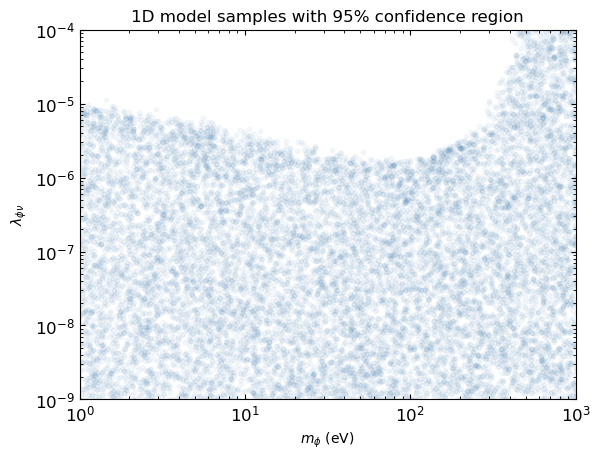

In [2]:
import corner
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2


threshold = chi2.ppf(0.95, df=2) # 95% confidence level for 2 parameters

fig, ax = plt.subplots()


path_1d = f'F:/Neutrino_SI/Bin/smellycat260605/data/1d_8p_1e6_p32_log_osc.npy'
arr_1d = np.load(path_1d)[:,-2:] # shape (32000, 2)
print(arr_1d.shape)
mean_1d = np.mean(arr_1d, axis=0)
cov_1d = np.cov(arr_1d, rowvar=False)
inv_cov_1d = np.linalg.inv(cov_1d)
diff_1d = arr_1d - mean_1d
mahalanobis_sq_1d = np.sum(np.dot(diff_1d, inv_cov_1d) * diff_1d, axis=1)

# Data points WITHIN 95% confidence
within_threshold_1d = mahalanobis_sq_1d <= threshold
arr_within_1d = arr_1d[within_threshold_1d]
arr_outside_1d = arr_1d[~within_threshold_1d]

ax.scatter(10**arr_within_1d[:, 0], 10**arr_within_1d[:, 1], s=10, alpha=0.05, color='steelblue')
# ax.scatter(10**arr_outside_1d[:, 0], 10**arr_outside_1d[:, 1], s=10, alpha=0.1, color='red')

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
ax.set_title('1D model samples with 95% confidence region')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m_{\phi}$ (eV)')
ax.set_ylabel(r'$\lambda_{\phi\nu}$')
ax.set_xlim(1, 1e3)
ax.set_ylim(1e-9, 1e-4)

fig

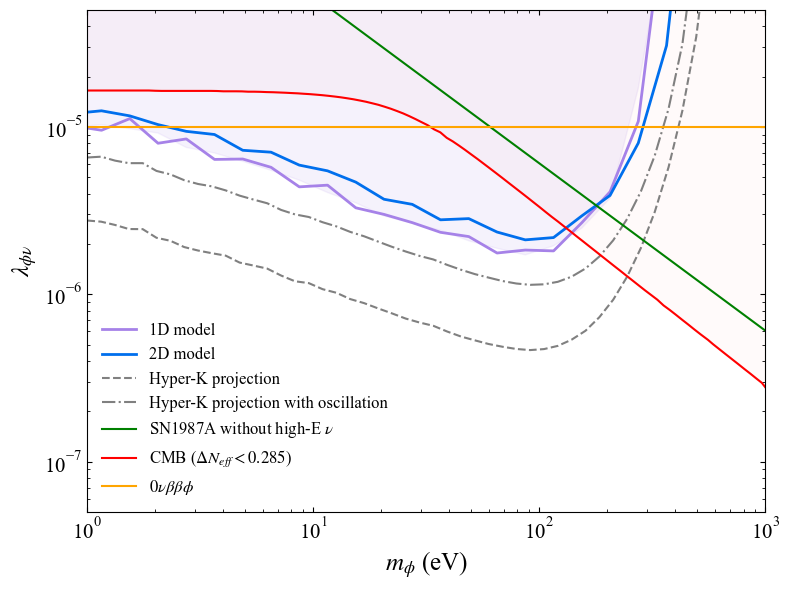

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
from scipy.signal import savgol_filter  # Import the smoothing filter

# Hyper-K projection data

m_x, l_y = 10**(np.load(r'F:\Neutrino_SI\Data\m_lambda_space_2d.npy').T)
m_x_osc, l_y_osc = 10**(np.load(r'F:\Neutrino_SI\Data\m_lambda_space_osc_2d.npy').T)


# 1d and 2d data within 95% confidence region
x_1d = arr_within_1d[:, 0]
y_1d = arr_within_1d[:, 1]

x_2d = arr_within_2d[:, 0]
y_2d = arr_within_2d[:, 1]

# the number of bins for the binned statistic
num_bins = 40

y_max_vals_1d, bin_edges_1d, _ = binned_statistic(x_1d, y_1d, statistic='max', bins=num_bins)
y_max_vals_2d, bin_edges_2d, _ = binned_statistic(x_2d, y_2d, statistic='max', bins=num_bins)

x_centers_1d = (bin_edges_1d[:-1] + bin_edges_1d[1:]) / 2
x_centers_2d = (bin_edges_2d[:-1] + bin_edges_2d[1:]) / 2

window_size = 5  # Adjust this depending on how aggressive you want the smoothing
y_smooth_1d = savgol_filter(y_max_vals_1d, window_length=window_size, polyorder=3)
y_smooth_2d = savgol_filter(y_max_vals_2d, window_length=window_size, polyorder=3)

fig, ax = plt.subplots(figsize=(8, 6))

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix' 
# STIX fonts look very similar to Times New Roman

label_fontsize = 18
tick_fontsize = 15

# ax.scatter(x, y, s=10, alpha=0.1, color='steelblue', label='Data')
ax.tick_params(axis='both', which='both', direction='in', 
               top=True, right=True, labelsize=12)


# Plot the extracted upper limit line
ax.plot(10**x_centers_1d, 10**y_max_vals_1d, linewidth=2, label='1D model', color ="#A682E8" )
ax.fill_between(10**x_centers_1d, 10**y_smooth_1d, 1e-4, color = "#A682E8", alpha = 0.1)

ax.plot(10**x_centers_2d, 10**y_max_vals_2d, linewidth=2, label='2D model', color = "#006FED")
# ax.fill_between(10**x_centers_2d, 10**y_smooth_2d, 1e-4, alpha=0.1)

ax.plot(m_x, l_y, label='Hyper-K projection', color='gray', linestyle='--')
ax.plot(m_x_osc, l_y_osc, label='Hyper-K projection with oscillation', color='gray', linestyle='-.')


g_y = 6.06e-4/m_x # from 3.71e-4 to 6.06e-4
ax.plot(m_x, g_y, label=r'SN1987A without high-E $\nu$', color='green')

m_cvb, g_cvb = np.loadtxt(r'F:\Neutrino_SI\Bin\dataset_xu_cvb_neff.csv', delimiter=',', unpack=True)
# print(m_cvb, g_cvb)
ax.plot(m_cvb, g_cvb, color='red', label=r'CMB ($\Delta N_{eff} < 0.285$)')
ax.fill_between(m_cvb, g_cvb, 1e-4, color='red', alpha=0.02)

ax.axhline(1e-5, color='orange', label=r'$0\nu\beta\beta\phi$')
# ax.fill_between(m_x, 1e-5, 1e-4, color='purple', alpha=0.1)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m_{\phi}$ (eV)', fontsize=label_fontsize)
ax.set_ylabel(r'$\lambda_{\phi\nu}$', fontsize=label_fontsize)
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=tick_fontsize)
ax.set_xlim(1, 1e3)
ax.set_ylim(5e-8, 5e-5)
# remove legend frame 
ax.legend(frameon=False, fontsize=12)

plt.tight_layout()
# plt.savefig(r"F:\Neutrino_SI\Plots\contrast_plot.pdf", bbox_inches='tight')
fig